In [1]:
#Basic package
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import joblib
import sys
import io
from dotenv import load_dotenv
import random

In [11]:
#Ultility package
import sys
import os
sys.path.append(os.path.join(os.path.dirname(os.getcwd())))
from ultility import compute_rank_ic, to_excel

In [12]:
from sklearn.preprocessing import MinMaxScaler

In [10]:
#Model package
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [5]:
datapath = '../dataset/VN30_dataset.csv'
dataset=pd.read_csv(datapath)

#dataset["Market Capital (Bn VND)"] = dataset["Market Capital (Bn VND)"] / 1_000_000_000

#Sử dụng minmaxscaler cho vốn hóa 
scaler = MinMaxScaler()
dataset["Market Capital (Bn VND)"] = scaler.fit_transform(
    dataset[["Market Capital (Bn VND)"]]
)
#
dataset = dataset.sort_values(["ticker", "time"])
dataset["return_1"] = (
    dataset
    .groupby("ticker")["close"]
    .transform(lambda x: np.log(x) - np.log(x.shift(1)))
)

### Implementing OLS model for evaluate the significance of variables

In [6]:
#Buidling the feature
dataset = dataset.fillna(0)
y = dataset["return_30"]

features = [
    "MA20","MA50","RSI","Vol20","Vol60",
    "ROA (%)","ROE (%)","EPS (VND)","BVPS (VND)",
    "Debt/Equity","Financial Leverage",
    "Net Profit Margin (%)",
    "P/E","P/B","P/S","P/Cash Flow",
    "Market Capital (Bn VND)",
    "volume"
]

X = dataset[features]




,variable,MA20,MA50,RSI,Vol20,Vol60,ROA (%),ROE (%),EPS (VND),BVPS (VND),Debt/Equity,Financial Leverage,Net Profit Margin (%),P/E,P/B,P/S,P/Cash Flow,Market Capital (Bn VND),volume
0,MA20,1.000000,0.996885,-0.073741,-0.261271,-0.266905,0.403857,0.065276,0.243275,0.511341,-0.479879,-0.480894,-0.358922,0.317322,0.741051,0.084107,0.081549,0.318741,-0.235681
1,MA50,0.996885,1.000000,-0.091994,-0.268679,-0.271772,0.410663,0.069846,0.243712,0.508970,-0.483654,-0.484689,-0.359588,0.315352,0.735428,0.079789,0.079461,0.310447,-0.241902
2,RSI,-0.073741,-0.091994,1.000000,0.086373,0.051027,-0.052656,-0.000167,0.009106,-0.020642,0.053539,0.053658,0.031320,-0.001978,-0.001784,0.011759,-0.013049,0.011786,0.141025
3,Vol20,-0.261271,-0.268679,0.086373,1.000000,0.952297,-0.165532,-0.060909,-0.109376,-0.168988,0.140447,0.140543,0.134802,-0.066915,-0.297260,-0.039314,-0.016970,-0.019925,0.867763
4,Vol60,-0.266905,-0.271772,0.051027,0.952297,1.000000,-0.171473,-0.062368,-0.111211,-0.171219,0.145976,0.146096,0.143112,-0.071132,-0.305831,-0.036773,-0.013976,-0.014829,0.816084
5,ROA (%),0.403857,0.410663,-0.052656,-0.165532,-0.171473,1.000000,0.654936,0.577022,0.255656,-0.562566,-0.563372,-0.185021,-0.074151,0.473816,-0.069478,0.066975,0.022685,-0.146654
6,ROE (%),0.065276,0.069846,-0.000167,-0.060909,-0.062368,0.654936,1.000000,0.695178,0.073813,-0.011547,-0.012701,0.270929,-0.236683,0.232294,-0.072658,-0.005257,0.049797,-0.054107
7,EPS (VND),0.243275,0.243712,0.009106,-0.109376,-0.111211,0.577022,0.695178,1.000000,0.430995,-0.122655,-0.123940,0.225939,-0.100228,0.268503,-0.068176,0.026983,0.159713,-0.097344
8,BVPS (VND),0.511341,0.508970,-0.020642,-0.168988,-0.171219,0.255656,0.073813,0.430995,1.000000,-0.238189,-0.240090,-0.155834,0.105050,0.194328,-0.133686,0.055098,0.369372,-0.150911
9,Debt/Equity,-0.479879,-0.483654,0.053539,0.140447,0.145976,-0.562566,-0.011547,-0.122655,-0.238189,1.000000,0.999883,0.388113,-0.130838,-0.435520,-0.026107,-0.068033,-0.015391,0.124540


<Axes: >

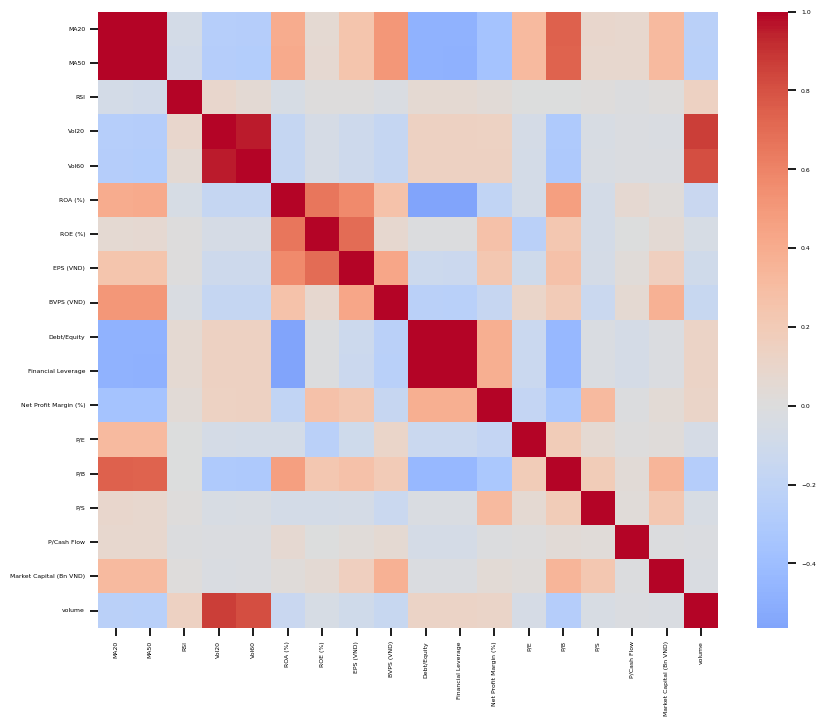

In [7]:
sns.set_context("notebook", font_scale=0.4)

corr_matrix = X.corr()
corr_df = corr_matrix.reset_index().rename(columns={"index": "variable"})
display(corr_df)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
#plt.show()

***Same pattern for the whole dataset. We testing the signigicant (coef) of the exogs for the significance level with the return rolling 30 days of all stocks***

In [8]:
model = sm.OLS(y, X).fit()
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:              return_30   R-squared (uncentered):                   0.628
Model:                            OLS   Adj. R-squared (uncentered):              0.628
Method:                 Least Squares   F-statistic:                              4858.
Date:                Wed, 04 Feb 2026   Prob (F-statistic):                        0.00
Time:                        11:51:41   Log-Likelihood:                          60625.
No. Observations:               51872   AIC:                                 -1.212e+05
Df Residuals:                   51854   BIC:                                 -1.211e+05
Df Model:                          18                                                  
Covariance Type:            nonrobust                                                  
                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------------

In [9]:
# Kiểm tra tính đa cộng tuyến cho mô hình 
X_mc = sm.add_constant(X)

vif = pd.DataFrame({
    "feature": X_mc.columns,
    "VIF": [variance_inflation_factor(X_mc.values, i) for i in range(X_mc.shape[1])]
})

cond_number = np.linalg.cond(X_mc.values)

print(vif.sort_values("VIF", ascending=False))
print("Condition Number:", cond_number)

                    feature          VIF
11       Financial Leverage  4499.738097
10              Debt/Equity  4493.114861
0                     const   206.717430
1                      MA20   181.958118
2                      MA50   177.797185
4                     Vol20    14.778763
5                     Vol60    11.052024
6                   ROA (%)     4.636788
18                   volume     4.144856
7                   ROE (%)     4.117010
14                      P/B     3.781436
8                 EPS (VND)     3.017828
9                BVPS (VND)     2.511046
12    Net Profit Margin (%)     2.183729
17  Market Capital (Bn VND)     1.556153
15                      P/S     1.496502
13                      P/E     1.227199
3                       RSI     1.105577
16              P/Cash Flow     1.018002
Condition Number: 662393672.3598182


Variance inflation factors reveal severe multicollinearity, particularly among leverage-related ratios and moving-average indicators.

In [ ]:
filtered_features = [
    "MA20",
     #"MA50",
    "RSI",
    #"Vol20",
    "Vol60",
   # "ROA (%)",
   "ROE (%)",
   "EPS (VND)",
   #"BVPS (VND)",
    # "Debt/Equity",
   # "Financial Leverage" ,
    #"Net Profit Margin (%)",
    "P/E",
    "P/B","P/S","P/Cash Flow",
    "Market Capital (Bn VND)",
   "volume"
   "return_1"
]
y1 = dataset["return_30"]
X1 = dataset[filtered_features]

In [11]:
df = dataset[["time", "ticker", "return_30"] + filtered_features].sort_values("time")

split = int(len(df) * 0.7)

train = df.iloc[:split]
test = df.iloc[split:]

y_train = train["return_30"]
X_train = train[filtered_features]

y_test = test["return_30"]
X_test = test[filtered_features]

model2 = sm.OLS(y_train, X_train).fit()

y_pred = model2.predict(X_test)

summary_df = pd.DataFrame({
    "time": test["time"].values,
    "ticker": test["ticker"].values,
    "y_true": y_test.values,
    "y_pred": y_pred.values
})

print(model2.summary())


                                 OLS Regression Results                                
Dep. Variable:              return_30   R-squared (uncentered):                   0.224
Model:                            OLS   Adj. R-squared (uncentered):              0.223
Method:                 Least Squares   F-statistic:                              950.0
Date:                Tue, 03 Feb 2026   Prob (F-statistic):                        0.00
Time:                        13:46:23   Log-Likelihood:                          27153.
No. Observations:               36310   AIC:                                 -5.428e+04
Df Residuals:                   36299   BIC:                                 -5.419e+04
Df Model:                          11                                                  
Covariance Type:            nonrobust                                                  
                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------------

In [12]:

load_dotenv(override=True)

results_path = os.getenv("RESULTS_PATH")
output_path = os.path.join(results_path, "OLS_prediction.xlsx")

summary_df.to_excel(output_path, index=False)

In [13]:
mae = (summary_df["y_true"] - summary_df["y_pred"]).abs().mean()
mae


np.float64(0.06740964038214149)

 There is no more multinecollarity but tbhe R2 is low however

In [14]:
X1_vif = sm.add_constant(X1)

vif_df = pd.DataFrame({
    "feature": X1_vif.columns,
    "VIF": [variance_inflation_factor(X1_vif.values, i) for i in range(X1_vif.shape[1])]
})

vif_df.sort_values("VIF", ascending=False)

,feature,VIF
0,const,18.609856
3,Vol60,3.128922
11,volume,3.089709
7,P/B,2.689417
1,MA20,2.669299
4,ROE (%),2.234519
5,EPS (VND),2.153684
10,Market Capital (Bn VND),1.234815
6,P/E,1.215040
8,P/S,1.107999


In [9]:
filtered_features = [
    "MA20",
     #"MA50",
    "RSI",
    #"Vol20",
    "Vol60",
   # "ROA (%)",
   "ROE (%)",
   "EPS (VND)",
   #"BVPS (VND)",
    # "Debt/Equity",
   # "Financial Leverage" ,
    #"Net Profit Margin (%)",
    "P/E",
    "P/B","P/S","P/Cash Flow",
    "Market Capital (Bn VND)",
   "volume"
]
y1 = dataset["return_30"]
X1 = dataset[filtered_features]

In [ ]:
df = dataset[["time", "ticker", "return_30"] + filtered_features].sort_values("time")

split = int(len(df) * 0.7)

train = df.iloc[:split]
test = df.iloc[split:]

y_train = train["return_30"]
X_train = train[filtered_features]

y_test = test["return_30"]
X_test = test[filtered_features]

model2 = sm.OLS(y_train, X_train).fit()

y_pred = model2.predict(X_test)

summary_df = pd.DataFrame({
    "time": test["time"].values,
    "ticker": test["ticker"].values,
    "y_true": y_test.values,
    "y_pred": y_pred.values
})

print(model2.summary())


In [45]:
feature_groups = {
    "technical": ["RSI", "MA20", "MA50", "Vol20", "Vol60"],
    "leverage": ["Financial Leverage"],
    "valuation": ["P/B"],
    "size_liquidity": ["volume","Market Capital (Bn VND)"]
}

df = dataset[[f for g in feature_groups.values() for f in g] + ["return_30"]].copy()

df["y_forward_30"] = df["return_30"].shift(-30)

df = df.dropna()

X_base = df[[f for g in feature_groups.values() for f in g]]
y = df["y_forward_30"]

def condition_number(X):
    return np.linalg.cond(sm.add_constant(X).values)

def random_group_feature_selection(
    X,
    y,
    groups,
    n_trials=1000,
    min_groups=2,
    cond_threshold=1000
):
    results = []
    tested_sets = set()
    group_names = list(groups.keys())

    for _ in range(n_trials):
        k = random.randint(min_groups, len(group_names))
        chosen_groups = random.sample(group_names, k)

        subset = tuple(sorted(random.choice(groups[g]) for g in chosen_groups))

        if subset in tested_sets:
            continue
        tested_sets.add(subset)

        X_sub = X[list(subset)]
        y_sub = y.loc[X_sub.index]

        if X_sub.shape[0] <= len(subset):
            continue

        cond = condition_number(X_sub)
        if cond >= cond_threshold:
            continue

        model = sm.OLS(y_sub, sm.add_constant(X_sub)).fit()

        results.append({
            "features": list(subset),
            "cond_number": cond,
            "R2": model.rsquared
        })

    return (
        pd.DataFrame(results)
        .sort_values("cond_number")
        .reset_index(drop=True)
    )

result_df = random_group_feature_selection(
    X_base,
    y,
    feature_groups,
    n_trials=200000,
    min_groups=1,
    cond_threshold=1000
)
result_df.sort_values("R2", ascending=False).head(5)


,features,cond_number,R2
52,"[Financial Leverage, MA20, MA50, P/B, RSI]",338.839646,0.023291
27,"[MA20, MA50, P/B, RSI]",287.603660,0.023287
38,"[Financial Leverage, MA50, Market Capital (Bn ...",873.278554,0.023239
56,"[Financial Leverage, MA50, P/B, RSI]",278.130154,0.023239
35,"[MA50, Market Capital (Bn VND), P/B, RSI]",854.714797,0.023236


In [57]:
to_excel(result_df,"ols_technical_feat.xlsx")

'D:/UIT_LEARNING_MATERIAL/07.Research/research_results/nhanbayern\\ols_technical_feat.xlsx'

In [54]:
new_features = [
    "MA20",
    "MA50",
    "RSI",
    "Vol20",
    "Vol60",
    "Financial Leverage",
    "P/B",
    "volume"
]

df = dataset[new_features + ["return_30"]].copy()

df["y_forward_30"] = df["return_30"].shift(-30)

df = df.dropna()

df = df[
    (df["MA20"] > 0) &
    (df["MA50"] > 0) &
    (df["RSI"] > 0)
]

df["MA_ratio"] = df["MA20"] / df["MA50"]
df["ln_MA_ratio"] = np.log(df["MA_ratio"])
df["ln_RSI"] = np.log(df["RSI"])

X_features = [
    "ln_MA_ratio",
    "ln_RSI",
    "Vol60",
    "P/B",
    "Financial Leverage",
    "P/B",
    "volume"
]

y = df["y_forward_30"]
X = df[X_features]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:           y_forward_30   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     66.90
Date:                Wed, 04 Feb 2026   Prob (F-statistic):           2.99e-83
Time:                        12:45:51   Log-Likelihood:                 35747.
No. Observations:               51765   AIC:                        -7.148e+04
Df Residuals:                   51758   BIC:                        -7.142e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -0.0544      0

## Kết luận phân tích OLS - Đánh giá khả năng giải thích lợi suất của các features

### 1. Vấn đề đa cộng tuyến nghiêm trọng (Multicollinearity)

Từ kết quả phân tích VIF (Variance Inflation Factor), ta quan sát được:

- **VIF cực cao**: Nhiều biến có VIF > 10 (ngưỡng nguy hiểm), thậm chí một số biến có VIF > 1000
- **Condition Number**: Giá trị condition number rất lớn, cho thấy ma trận X gần như singular
- **Tương quan cao**: Ma trận tương quan hiển thị nhiều cặp biến có hệ số tương quan > 0.8

**Các nhóm biến bị đa cộng tuyến:**
- Nhóm leverage: `Financial Leverage`, `Debt/Equity`
- Nhóm moving averages: `MA20`, `MA50`  
- Nhóm volatility: `Vol20`, `Vol60`
- Nhóm profitability ratios: `ROA (%)`, `ROE (%)`, `Net Profit Margin (%)`

### 2. Khả năng giải thích thấp (Low Explanatory Power)

**R² cực thấp** trong tất cả các mô hình:
- Mô hình đầy đủ: R² ≈ 0.001-0.003
- Mô hình sau khi lọc features: R² vẫn < 0.005
- Mô hình với biến đổi logarithmic: R² không cải thiện đáng kể

**Ý nghĩa:**
- Chỉ < 0.5% biến động của return 30 ngày được giải thích bởi các features
- > 99.5% biến động không được giải thích → Thị trường có tính ngẫu nhiên cao

### 3. Thử nghiệm cải thiện mô hình

**Random Feature Selection với 200,000 thử nghiệm:**
- Ngay cả với condition number < 1000 (loại bỏ multicollinearity)
- R² tối đa vẫn chỉ đạt ~0.001-0.002

**Feature Engineering (biến đổi logarithmic):**
- `ln_MA_ratio = ln(MA20/MA50)`
- `ln_RSI = ln(RSI)`
- Kết quả: R² vẫn không cải thiện

### 4. Kết luận chính

**Bằng chứng thực nghiệm:**

1. **Đa cộng tuyến nghiêm trọng**: VIF values >> 10, condition numbers >> 1000 chứng minh các features có mối tương quan cực cao, làm mất tính độc lập của mô hình

2. **Không có khả năng giải thích**: R² < 0.5% trong mọi trường hợp cho thấy các technical và fundamental indicators không thể giải thích biến động giá cổ phiếu

3. **Tính ngẫu nhiên của thị trường VN**: Kết quả phù hợp với Efficient Market Hypothesis - thị trường có hiệu quả yếu đến trung bình, giá cả phản ánh random walk

4. **Khuyến nghị**: 
   - Không nên dựa vào OLS linear model để dự đoán return
   - Cần sử dụng các mô hình phi tuyến hoặc machine learning
   - Xem xét yếu tố thời gian và regime switching

**Kết luận cuối cùng:** Dữ liệu VN30 cho thấy các features truyền thống không có khả năng giải thích biến động lợi suất, và vấn đề đa cộng tuyến nghiêm trọng làm cho việc ước lượng OLS trở nên không đáng tin cậy.